In [1]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import signal

In [2]:
in_dir = "simulations/static"

fs = 10
n_samples = 1000
n_time = 10000
buffer = 100  # time before and after central signal to allow, in seconds
n_total_time = n_time + (buffer * 2 * fs)
n_signals = 3

/opt/miniconda3/envs/py311/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]


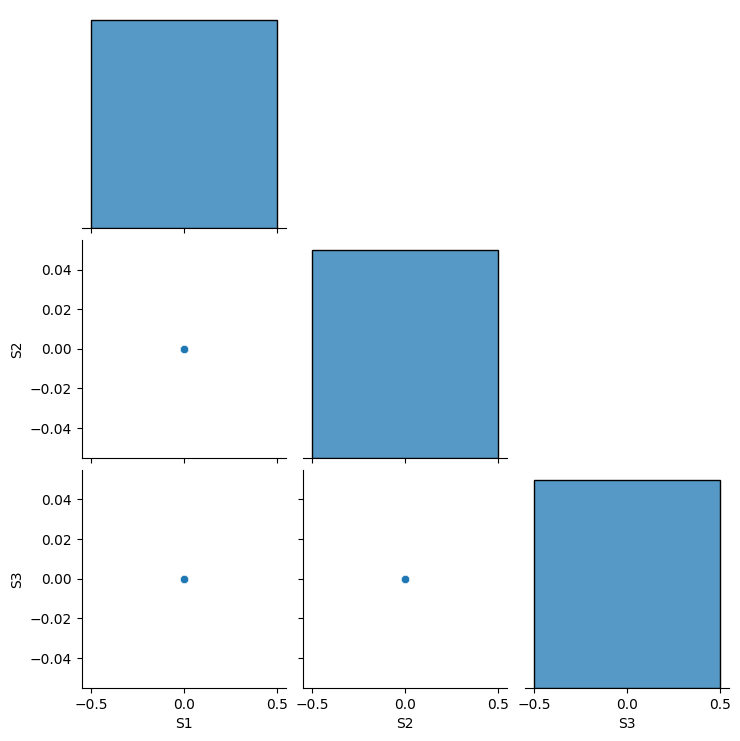

In [3]:
same_delays = True
if same_delays:
    delays = np.random.normal(loc=0, scale=buffer / 2, size=(n_samples))
    delays = np.ones((n_samples, n_signals)) * delays[:, None]
else:
    delays = np.random.normal(loc=0, scale=buffer / 2, size=(n_samples, n_signals))

# Make one of the signals fully static
delays[:, -1] = 0
delays = np.zeros_like(delays)

delays = np.round(delays, 1)
delays[delays < -buffer] = -buffer
delays[delays > buffer] = buffer

# Sort by overall delay to make data easier to look at
delay_sums = np.sum(delays, axis=1)
idx = delay_sums.argsort()
delays = delays[idx, :]
print(np.corrcoef(delays.T))

delay_df = pd.DataFrame(columns=["S1", "S2", "S3"], data=delays)
out = sns.pairplot(delay_df, corner=True)
out.savefig(os.path.join(in_dir, "delay_pairplot.png"))

[[ 1.          0.01081387 -0.03243401]
 [ 0.01081387  1.          0.01637326]
 [-0.03243401  0.01637326  1.        ]]


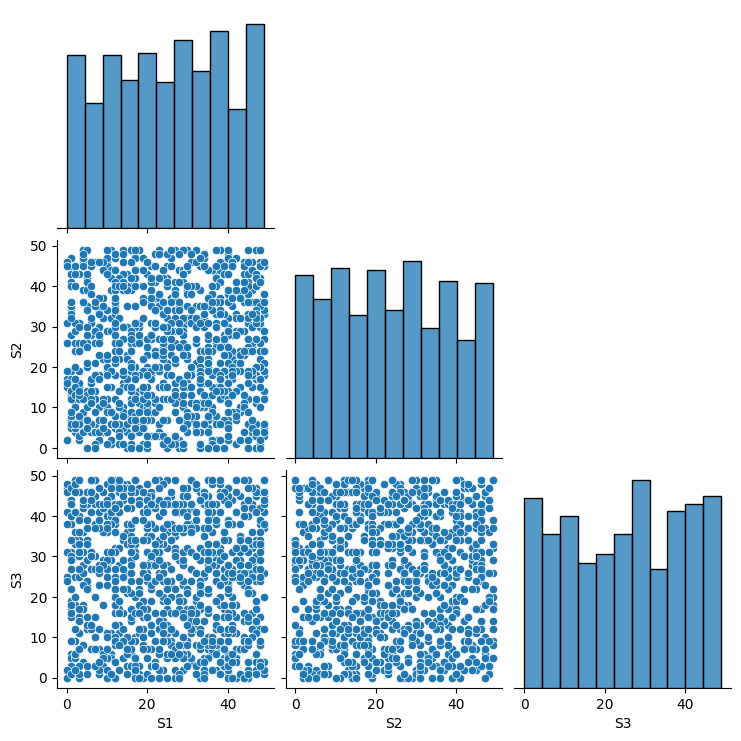

In [4]:
amps = np.random.randint(0, 50, size=(n_samples, n_signals))
print(np.corrcoef(amps.T))

amps_df = pd.DataFrame(columns=["S1", "S2", "S3"], data=amps)
sns.pairplot(amps_df, corner=True)

[[ 1.          0.01123789 -0.04331694]
 [ 0.01123789  1.          0.05419961]
 [-0.04331694  0.05419961  1.        ]]


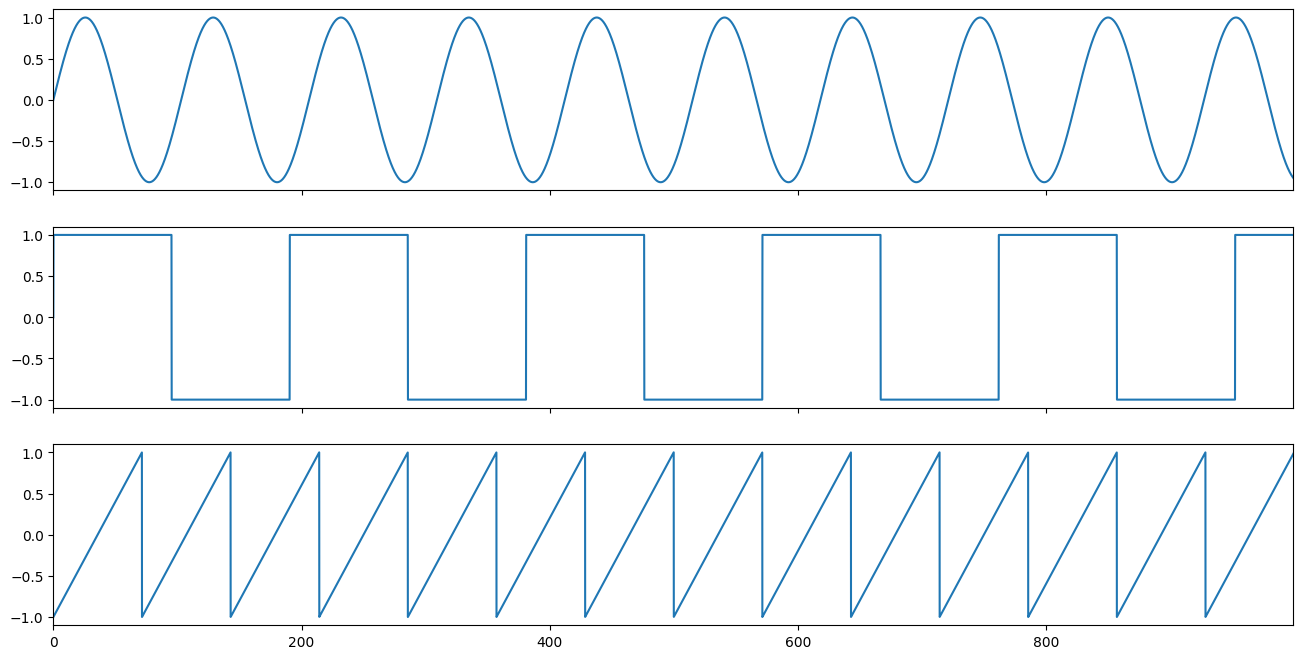

In [5]:
time = np.linspace(0, 1000, n_total_time)
s1 = np.sin(np.linspace(0, 61, n_total_time))  # Signal 1 : sinusoidal signal
s2 = np.sign(np.sin(np.linspace(0, 33, n_total_time)))  # Signal 2 : square signal
s3 = signal.sawtooth(np.linspace(0, 88, n_total_time))  # Signal 3: saw tooth signal
orig_signals = np.vstack((s1, s2, s3))

fig, axes = plt.subplots(nrows=n_signals, sharex=True, figsize=(16, 8))
for i_signal in range(n_signals):
    axes[i_signal].plot(time, orig_signals[i_signal, :])
axes[0].set_xlim(0, np.max(time) - 1)
fig.savefig(os.path.join(in_dir, "orig_signals.png"))
print(np.corrcoef(orig_signals))

In [6]:
# Create volumes-by-voxels data array composed of scaled, delayed, and summed components
start_point = buffer * fs
data = np.zeros((n_time, n_samples))
for i_voxel in range(n_samples):
    scaled_signals = orig_signals * amps[i_voxel, :][:, None]
    voxel_delays = -1 * delays[i_voxel, :] * fs
    for j_signal in range(n_signals):
        voxel_delay = int(voxel_delays[j_signal]) + start_point
        scaled_signal = scaled_signals[j_signal, :]
        scaled_signal = scaled_signal[voxel_delay:n_time + voxel_delay]
        data[:, i_voxel] += scaled_signal

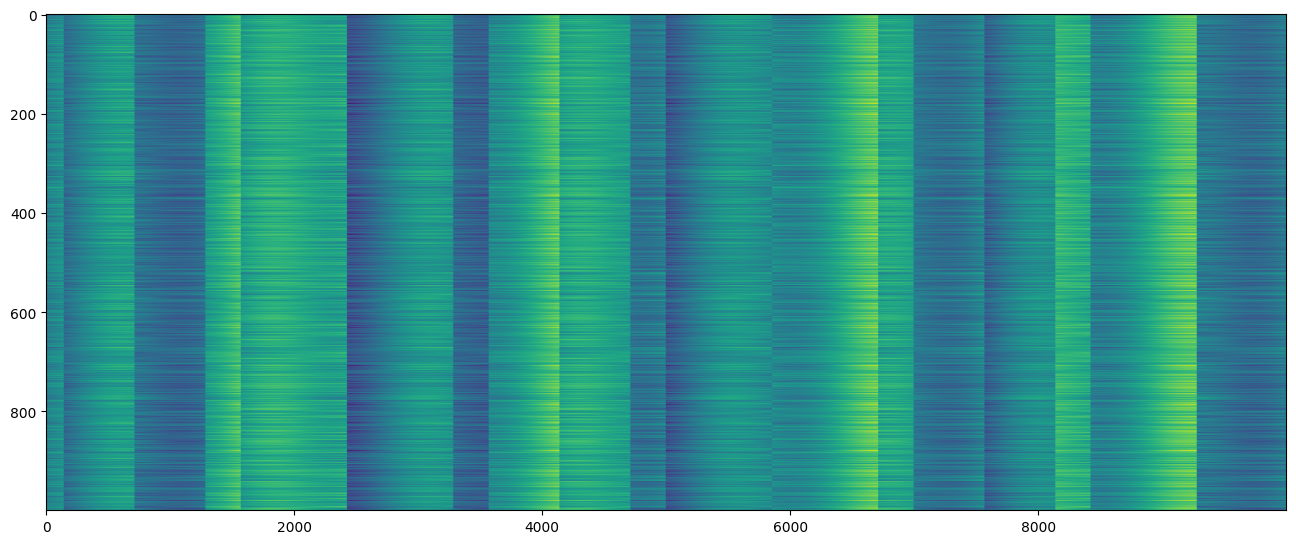

In [7]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(data.T, aspect=4)
fig.savefig(os.path.join(in_dir, "data.png"))

In [8]:
np.savetxt(os.path.join(in_dir, "data.txt"), data)

In [9]:
np.savetxt(os.path.join(in_dir, "delays.txt"), delays)

In [10]:
np.savetxt(os.path.join(in_dir, "weights.txt"), amps)

In [11]:
np.savetxt(os.path.join(in_dir, "components.txt"), orig_signals[:, buffer*fs:-buffer*fs])